In [7]:
import pandas as pd

df = pd.read_excel("Mahasiswa_Lulus.xlsx")

display(df.head())

,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa,Status_Kelulusan
0,3.93,100,5,No,15000,Male,Yes,LULUS
1,3.90,90,2,No,20000,Male,Yes,LULUS
2,3.59,98,3,Yes,100000,Female,Yes,LULUS
3,3.78,100,5,Yes,40000,Female,No,LULUS
4,3.81,100,4,No,50000,Male,Yes,LULUS


In [8]:
print(df.isnull().sum())

IPK                 0
Kehadiran           0
Jam_Belajar         0
Organisasi          0
Penghasilan_Ortu    0
Jenis_Kelamin       0
Status_Beasiswa     0
Status_Kelulusan    0
dtype: int64


In [9]:
X = df.drop("Status_Kelulusan", axis=1)
y = df["Status_Kelulusan"]

In [10]:
X = pd.get_dummies(
    X,
    columns=[
        "Organisasi",
        "Jenis_Kelamin",
        "Status_Beasiswa"
    ]
)

y = y.map({
    "LULUS": 1,
    "TIDAK LULUS": 0
})

display(X.head())
display(y.head())

,IPK,Kehadiran,Jam_Belajar,Penghasilan_Ortu,Organisasi_No,Organisasi_Yes,Jenis_Kelamin_Female,Jenis_Kelamin_Male,Status_Beasiswa_No,Status_Beasiswa_Yes
0,3.93,100,5,15000,True,False,False,True,False,True
1,3.90,90,2,20000,True,False,False,True,False,True
2,3.59,98,3,100000,False,True,True,False,False,True
3,3.78,100,5,40000,False,True,True,False,True,False
4,3.81,100,4,50000,True,False,False,True,False,True


,Status_Kelulusan
0,1
1,1
2,1
3,1
4,1


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Data training: (400, 10)
Data testing: (100, 10)


In [12]:
from sklearn.tree import DecisionTreeClassifier

model_dt_3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model_dt_3.fit(X_train, y_train)

y_pred_dt_3 = model_dt_3.predict(X_test)

In [13]:
model_dt_none = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

model_dt_none.fit(X_train, y_train)

y_pred_dt_none = model_dt_none.predict(X_test)

In [14]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()

model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluasi_model(nama_model, y_aktual, y_prediksi):
    print(f"=== {nama_model} ===")
    print("Accuracy :", accuracy_score(y_aktual, y_prediksi))
    print("Precision:", precision_score(
        y_aktual,
        y_prediksi,
        zero_division=0
    ))
    print("Recall   :", recall_score(
        y_aktual,
        y_prediksi,
        zero_division=0
    ))
    print("F1-Score :", f1_score(
        y_aktual,
        y_prediksi,
        zero_division=0
    ))
    print()

In [16]:
evaluasi_model(
    "Decision Tree max_depth=3",
    y_test,
    y_pred_dt_3
)

evaluasi_model(
    "Decision Tree max_depth=None",
    y_test,
    y_pred_dt_none
)

evaluasi_model(
    "Gaussian Naive Bayes",
    y_test,
    y_pred_nb
)

=== Decision Tree max_depth=3 ===
Accuracy : 0.9
Precision: 0.925
Recall   : 0.9487179487179487
F1-Score : 0.9367088607594937

=== Decision Tree max_depth=None ===
Accuracy : 0.8
Precision: 0.8918918918918919
Recall   : 0.8461538461538461
F1-Score : 0.868421052631579

=== Gaussian Naive Bayes ===
Accuracy : 0.85
Precision: 0.8461538461538461
Recall   : 0.9871794871794872
F1-Score : 0.9112426035502958



In [17]:
hasil_evaluasi = pd.DataFrame({
    "Model": [
        "Decision Tree max_depth=3",
        "Decision Tree max_depth=None",
        "Gaussian Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt_3),
        accuracy_score(y_test, y_pred_dt_none),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt_3, zero_division=0),
        precision_score(y_test, y_pred_dt_none, zero_division=0),
        precision_score(y_test, y_pred_nb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt_3, zero_division=0),
        recall_score(y_test, y_pred_dt_none, zero_division=0),
        recall_score(y_test, y_pred_nb, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dt_3, zero_division=0),
        f1_score(y_test, y_pred_dt_none, zero_division=0),
        f1_score(y_test, y_pred_nb, zero_division=0)
    ]
})

display(hasil_evaluasi)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree max_depth=3,0.90,0.925000,0.948718,0.936709
1,Decision Tree max_depth=None,0.80,0.891892,0.846154,0.868421
2,Gaussian Naive Bayes,0.85,0.846154,0.987179,0.911243


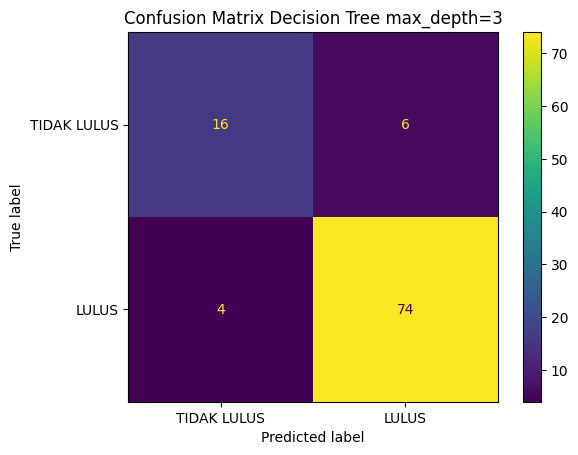

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt_3 = confusion_matrix(y_test, y_pred_dt_3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_3,
    display_labels=["TIDAK LULUS", "LULUS"]
)

disp.plot()
plt.title("Confusion Matrix Decision Tree max_depth=3")
plt.show()

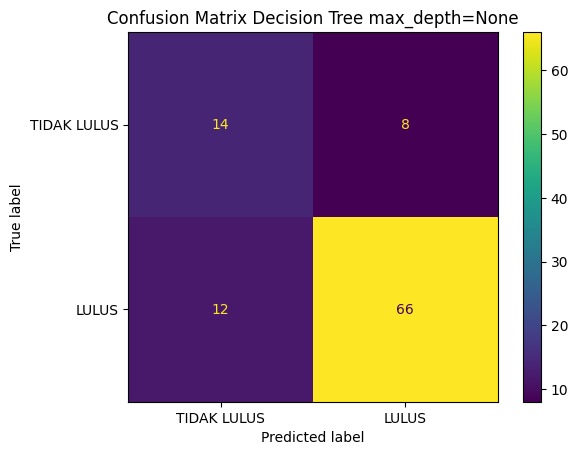

In [19]:
cm_dt_none = confusion_matrix(y_test, y_pred_dt_none)

ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_none,
    display_labels=["TIDAK LULUS", "LULUS"]
).plot()

plt.title("Confusion Matrix Decision Tree max_depth=None")
plt.show()

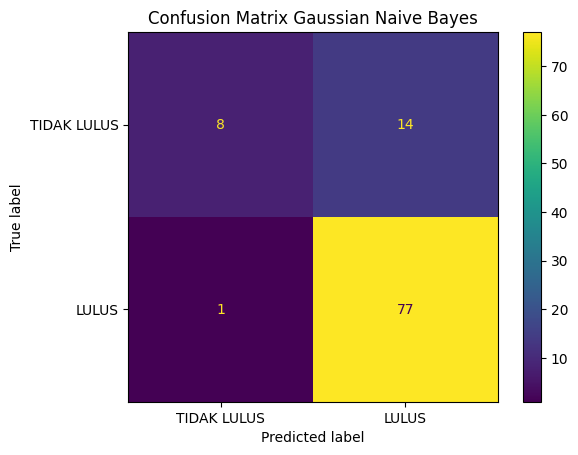

In [20]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["TIDAK LULUS", "LULUS"]
).plot()

plt.title("Confusion Matrix Gaussian Naive Bayes")
plt.show()

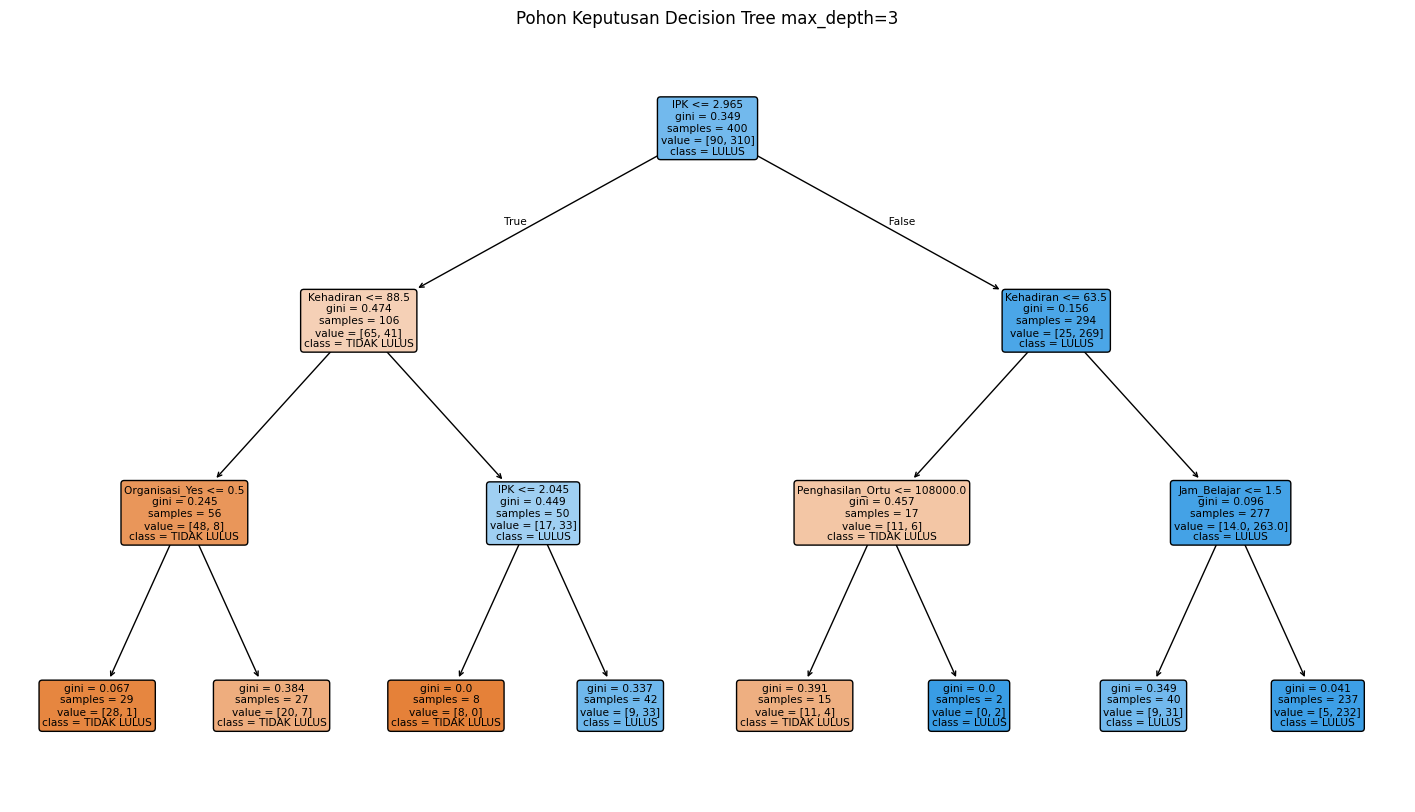

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model_dt_3,
    feature_names=X.columns,
    class_names=["TIDAK LULUS", "LULUS"],
    filled=True,
    rounded=True
)

plt.title("Pohon Keputusan Decision Tree max_depth=3")
plt.show()

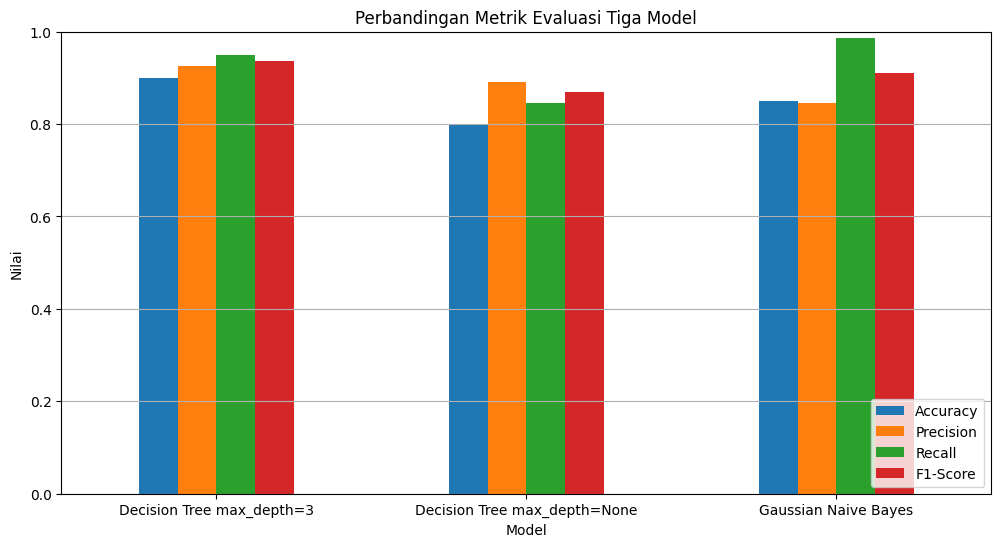

In [22]:
hasil_evaluasi.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Perbandingan Metrik Evaluasi Tiga Model")
plt.xlabel("Model")
plt.ylabel("Nilai")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

In [23]:
hasil_prediksi = X_test.copy()

hasil_prediksi["Aktual"] = y_test
hasil_prediksi["Prediksi"] = y_pred_dt_3

In [24]:
data_salah = hasil_prediksi[
    hasil_prediksi["Aktual"] != hasil_prediksi["Prediksi"]
]

display(data_salah.head(5))

,IPK,Kehadiran,Jam_Belajar,Penghasilan_Ortu,Organisasi_No,Organisasi_Yes,Jenis_Kelamin_Female,Jenis_Kelamin_Male,Status_Beasiswa_No,Status_Beasiswa_Yes,Aktual,Prediksi
19,3.15,90,2,40000,True,False,True,False,False,True,0,1
263,2.94,100,1,121000,False,True,False,True,True,False,0,1
475,2.80,90,2,30000,True,False,False,True,False,True,0,1
110,2.77,95,1,40000,False,True,False,True,True,False,0,1
160,3.15,82,2,40000,True,False,False,True,False,True,0,1


In [25]:
print(
    "Jumlah data yang salah diprediksi:",
    len(data_salah)
)

Jumlah data yang salah diprediksi: 10


In [26]:
data_salah_lengkap = data_salah.copy()

data_salah_lengkap["Aktual"] = data_salah_lengkap["Aktual"].map({
    1: "LULUS",
    0: "TIDAK LULUS"
})

data_salah_lengkap["Prediksi"] = data_salah_lengkap["Prediksi"].map({
    1: "LULUS",
    0: "TIDAK LULUS"
})

display(data_salah_lengkap.head(5))

,IPK,Kehadiran,Jam_Belajar,Penghasilan_Ortu,Organisasi_No,Organisasi_Yes,Jenis_Kelamin_Female,Jenis_Kelamin_Male,Status_Beasiswa_No,Status_Beasiswa_Yes,Aktual,Prediksi
19,3.15,90,2,40000,True,False,True,False,False,True,TIDAK LULUS,LULUS
263,2.94,100,1,121000,False,True,False,True,True,False,TIDAK LULUS,LULUS
475,2.80,90,2,30000,True,False,False,True,False,True,TIDAK LULUS,LULUS
110,2.77,95,1,40000,False,True,False,True,True,False,TIDAK LULUS,LULUS
160,3.15,82,2,40000,True,False,False,True,False,True,TIDAK LULUS,LULUS


In [27]:

mahasiswa_simulasi = pd.DataFrame({
    "IPK": [3.80],
    "Kehadiran": [50],
    "Jam_Belajar": [4],
    "Penghasilan_Ortu": [50000],
    "Organisasi_No": [1],
    "Organisasi_Yes": [0],
    "Jenis_Kelamin_Female": [0],
    "Jenis_Kelamin_Male": [1],
    "Status_Beasiswa_No": [1],
    "Status_Beasiswa_Yes": [0]
})

mahasiswa_simulasi = mahasiswa_simulasi[X.columns]

print("PROFIL MAHASISWA SIMULASI")
display(mahasiswa_simulasi)

pred_dt_3 = model_dt_3.predict(mahasiswa_simulasi)[0]
pred_dt_none = model_dt_none.predict(mahasiswa_simulasi)[0]
pred_nb = model_nb.predict(mahasiswa_simulasi)[0]

label = {
    0: "TIDAK LULUS",
    1: "LULUS"
}

hasil_simulasi = pd.DataFrame({
    "Model": [
        "Decision Tree (max_depth=3)",
        "Decision Tree (max_depth=None)",
        "GaussianNB"
    ],
    "Prediksi": [
        label[pred_dt_3],
        label[pred_dt_none],
        label[pred_nb]
    ]
})

print("\nHASIL PREDIKSI")
display(hasil_simulasi)

PROFIL MAHASISWA SIMULASI


,IPK,Kehadiran,Jam_Belajar,Penghasilan_Ortu,Organisasi_No,Organisasi_Yes,Jenis_Kelamin_Female,Jenis_Kelamin_Male,Status_Beasiswa_No,Status_Beasiswa_Yes
0,3.8,50,4,50000,1,0,0,1,1,0



HASIL PREDIKSI


,Model,Prediksi
0,Decision Tree (max_depth=3),TIDAK LULUS
1,Decision Tree (max_depth=None),TIDAK LULUS
2,GaussianNB,TIDAK LULUS
